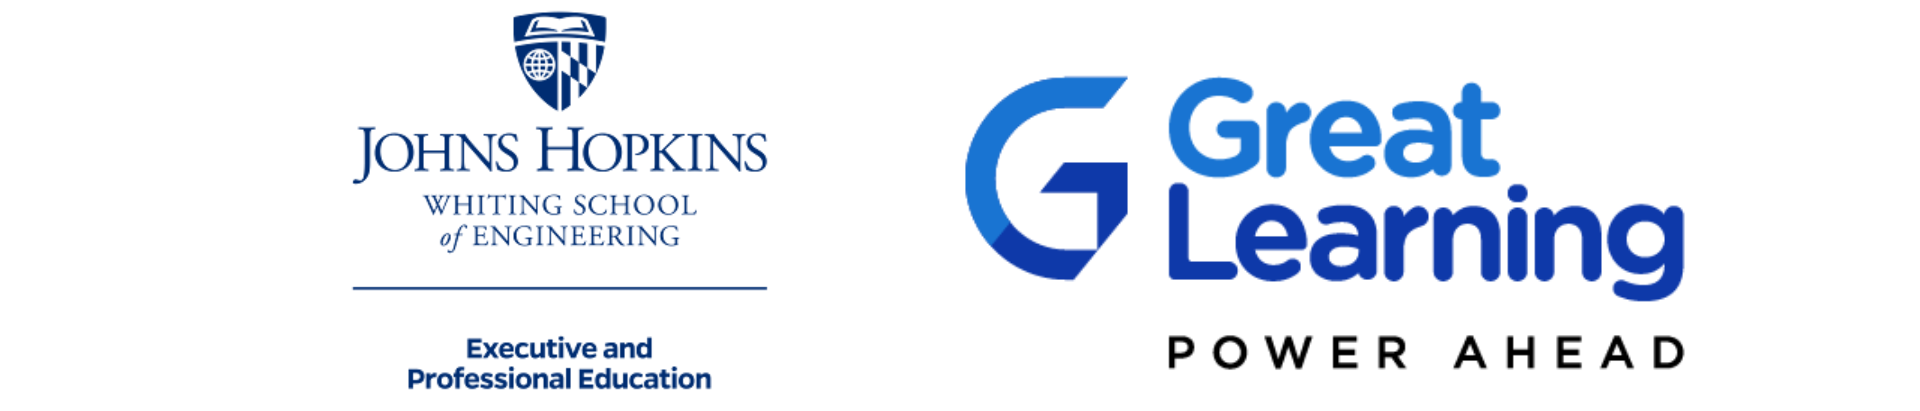

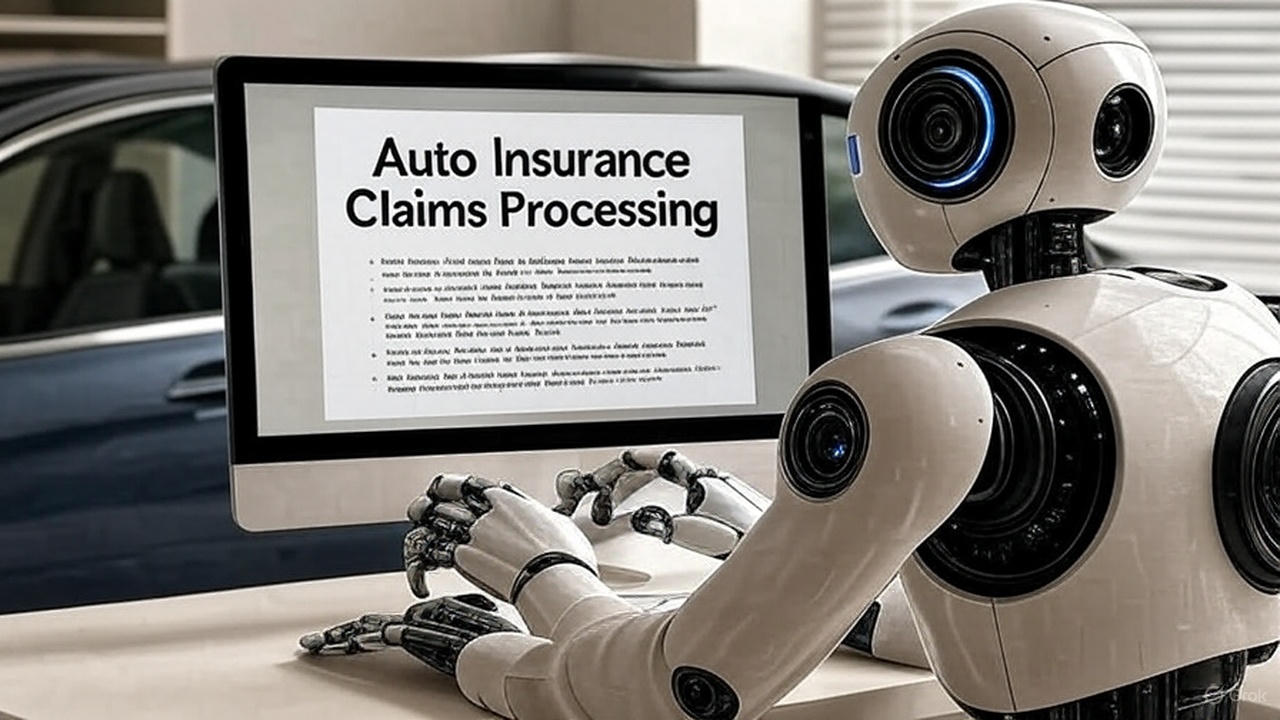

# Learning Objective

- Implement a RAG-powered Agentic application using the **smolagents** package, showcasing the integration of a Knowledge Base, Retriever and Generator within a single agent system.

# Business Case: Auto Insurance Claims Processing

In the auto insurance industry, the claim process is predominantly manual. Claims executives manually parse invoices to extract key details, cross-reference vendor contracts to verify terms and compliance, and validate payments against policy stipulations. This process requires extensive review of complex policy documents, relying heavily on the executive's subject matter expertise and judgment to adjudicate claims.

## Problem Scenario

Due to its manual nature, claims processing is susceptible to delays. Policy documents are extensive and updated regularly, making it challenging for human operators to stay current with all changes. Manual errors, such as rejecting claims on invalid grounds, can lead to client frustration and dissatisfaction. Consequently, these inefficiencies lead to prolonged processing times, higher operational costs (in the long term), and potential reputational damage.

## Proposed Solution

The solution proposed is to develop an automated insurance claims processing system powered by Agentic Retrieval-Augmented Generation (Agentic RAG) capabilities. This solution embeds single AI agents with a knowledge base into a RAG pipeline. The system retrieves relevant policy details and integrates them with user claim data, validating claims through a web search against current policy information and regulations. It also generates adjudication recommendations while ensuring compliance with regulatory requirements.

The advantages include time savings, long-term cost reduction, improved accuracy through validity checks, and enhanced client satisfaction.

## Why AgenticRAG Over Traditional RAG ?

Traditional RAG systems rely on static workflows, limiting their adaptability for complex, multi-step tasks. AgenticRAG, however, uses agentic design patterns - **reflection**, **planning**, **tool use**, and **collaboration** to dynamically manage retrieval, refine context, and adapt workflows. With flexible operational structures, from sequential to collaborative, AgenticRAG offers superior flexibility, scalability, and context-awareness, making it ideal for dynamic applications like automated claims processing.

In [1]:
## setup
# openai: for using the OpenAI API and GPT models
# smolagents[toolkit]: SmolaAgent framework with tools
# chromadb: vector database for embeddings and retrieval
# PyPDF2: for reading and processing PDF files
!pip install -q openai==2.7.1 \
                smolagents[toolkit]==1.22.0 \
                chromadb==1.3.4 \
                PyPDF2==3.0.1


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 5.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.8/149.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.8/20.8 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.3 MB/s eta 0:

# Claim Processing Notebook Overview

This notebook implements an automated claim processing workflow using a sequence of specialized tools. The process begins with **parsing the incoming claim** using `parse_claim`, which extracts relevant information from the JSON payload. Next, `is_valid_query` validates the claim to ensure it meets basic criteria. If the claim is invalid, the workflow immediately generates a **final decision of invalid**.

For valid claims, the notebook proceeds to **policy evaluation**. The `generate_policy_queries` tool formulates queries to retrieve relevant policy details, and `retrieve_policy_text` fetches the corresponding policy information. Using these insights, `generate_recommendation` creates an initial recommendation for claim approval or denial.

Before issuing the final decision, the notebook performs a **price check** to identify any discrepancies. If the price is inflated, the workflow outputs a **final decision of inflated**; otherwise, it confirms the recommendation and produces the **final decision** using `finalize_decision`.

Overall, the notebook orchestrates a structured, step-by-step evaluation of claims, combining validation, policy retrieval, recommendation generation, and final decision-making in an automated and systematic manner.


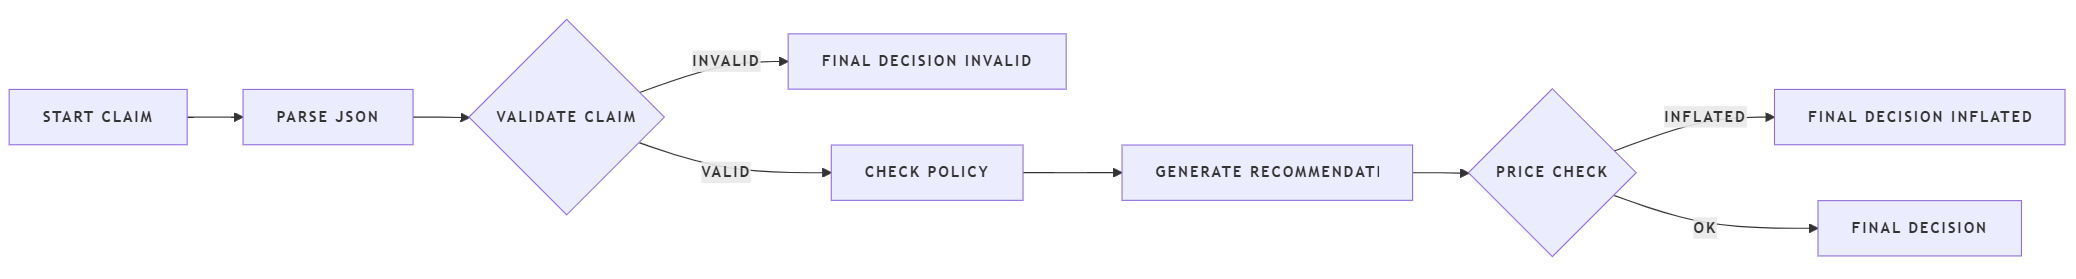

## Imports & Environment Setup

In [2]:
# imports
import json
import os
import time
import re
from typing import List, Optional

import chromadb
import PyPDF2
from google.colab import userdata
from pydantic import BaseModel, Field
from sentence_transformers import SentenceTransformer

from smolagents import (
    tool,
    ToolCallingAgent,
    WebSearchTool,
    OpenAIServerModel,
    PromptTemplates,
    PlanningPromptTemplate,
    ManagedAgentPromptTemplate,
    FinalAnswerPromptTemplate,
)

In [4]:
# Load the JSON file and extract values
file_name = 'config.json'
with open(file_name, 'r') as file:
    config = json.load(file)
    os.environ['OPENAI_API_KEY'] = config.get("API_KEY") # Loading the API Key
    os.environ["OPENAI_BASE_URL"] = config.get("OPENAI_API_BASE") # Loading the API Base Url

## LLM
**GPT-4o-mini** will be used as the LLM.

In [5]:
## LLM Setup
model = OpenAIServerModel(
    model_id="gpt-4o-mini",
    api_base=os.environ['OPENAI_BASE_URL'],
    api_key=os.environ['OPENAI_API_KEY'],
)

## Embedding Model

The 'all-MiniLM-L6-v2' pretrained embedding model will be used for converting sentences and words into numerical (vectors).

In [6]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Auto Loan Processing Agent Schemas
### BaseModel
The `BaseModel` is a foundational class used to define data structures in the schema, providing validation and serialization features for the derived classes.

### ClaimInfo
Stores detailed information about an insurance claim, including claimant, policy, loss details etc.

### PolicyQueries
Stores a list of search queries used to retrieve relevant policy sections for a claim.

### PolicyRecommendation
Represents the coverage assessment and recommended financial terms based on the policy.

### ClaimDecision
Captures the final determination of coverage and recommended payout for a claim.

In [7]:
class ClaimInfo(BaseModel):
    """Extracted insurance claim information."""
    claim_number: str
    policy_number: str
    claimant_name: str
    date_of_loss: str
    loss_description: str
    estimated_repair_cost: float
    vehicle_details: Optional[str] = None

In [8]:
class PolicyQueries(BaseModel):
    queries: List[str] = Field(
        default_factory=list,
        description="A list of query strings to retrieve relevant policy sections."
    )

In [9]:
class PolicyRecommendation(BaseModel):
    """Policy recommendation regarding a given claim."""
    policy_section: str = Field(..., description="The policy section or clause that applies.")
    recommendation_summary: str = Field(..., description="A concise summary of coverage determination.")
    deductible: Optional[float] = Field(None, description="The applicable deductible amount.")
    settlement_amount: Optional[float] = Field(None, description="Recommended settlement payout.")

In [10]:
class ClaimDecision(BaseModel):
    claim_number: str
    covered: bool
    deductible: float
    recommended_payout: float
    notes: Optional[str] = None

## ChromaDB Setup
Setting up the Chroma vector database client and collection for storing and retrieving policy document.

In [11]:
#Initialize ChromaDB and creating collection
chroma_client = chromadb.Client()
collection_name = "auto_insurance_policy"

try:
    collection = chroma_client.get_or_create_collection(name=collection_name)
except Exception as e:
    print(f"Error creating collection: {e}")
    collection = chroma_client.create_collection(name=collection_name)

The policy document will be uploaded and then divided into sections called **chunks**.

Here, each page is considered a chunk.

Finally, the chunks will be vectorized using an embedding model before being inserted into our vector database - ChromaDB.

In [12]:
# Do make sure the file is uploaded in the below path
policy_file_path = "/content/policy.pdf"

with open(policy_file_path, "rb") as f:
    reader = PyPDF2.PdfReader(f)
    policy_text = ""
    for page in reader.pages:
        policy_text += page.extract_text()

# Split policy text into chunks (e.g., by page)
policy_chunks = policy_text.split("\n\n")
chunk_ids = [f"chunk_{i}" for i in range(len(policy_chunks))]
chunk_embeddings = embedder.encode(policy_chunks)

# Add chunks to ChromaDB
collection.add(
    documents=policy_chunks,
    embeddings=chunk_embeddings,
    ids=chunk_ids
)

## Define Tools

Define custom tools for parsing claims, generating queries, retrieving policy text, generating recommendations, and finalizing decisions.

### **Tool 1: Parse Claim**

This tool processes a user-provided claim file and converts it into a validated, structured format for downstream analysis. It reads a JSON file from the given path, loads the raw claim data, and uses the `ClaimInfo` model to ensure the contents are complete and correctly structured. If the data is valid, the tool returns a normalized JSON string representation of the claim. If the file cannot be read or the data fails validation, it returns a clear and descriptive error message. This tool serves as the entry point of the claims workflow, ensuring that all subsequent tools operate on clean, reliable, and standardized claim information.


In [13]:
import datetime
@tool
def parse_claim(file_path: str) -> str:
    """
    Parse a claim JSON file and return structured ClaimInfo data.

    Args:
        file_path (str): Path to the JSON file containing claim data.
    """
    print("[INSIDE TOOL]: parse_claim")
    try:
        with open(file_path, "r") as f:
            data = json.load(f)
        claim_info = ClaimInfo.model_validate(data)
        return claim_info.model_dump_json()
    except Exception as e:
        return f"Error parsing claim: {str(e)}"

### **Tool 2: Validate Claim Query**

This tool evaluates whether a parsed insurance claim is valid based on policy records stored in a CSV file. It begins by reconstructing the `ClaimInfo` object from the JSON input produced by Tool 1, ensuring the claim data is properly structured. The tool then loads the policy coverage dataset and attempts to match the claim’s policy number. Once located, it performs several checks: confirming there are no outstanding dues and verifying that the reported loss date falls within the policy’s active coverage period. If any requirement fails, the tool returns `False` along with a clear explanation of the issue. When all conditions are satisfied, it returns `True` with a confirmation message, making it an essential decision layer in the claims validation workflow.


In [14]:
@tool
def is_valid_query(query: str) -> bool | str:
    """
    Check if the claim made by the user is valid and return a boolean value, with reason.
    Args:
        query (str): The parsed text in json format from the parser tool with all the information.
    """
    try:
        # Parse claim object
        claim_info = ClaimInfo.model_validate_json(query)

        # Load coverage_data.csv instead of JSON
        import csv
        coverage_data = []
        with open("coverage_data.csv", "r", newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for row in reader:
                coverage_data.append(row)

    except Exception as e:
        return f"Error : {str(e)}"

    # Find matching policy
    policy = next(
        (p for p in coverage_data if p["policy_number"] == claim_info.policy_number),
        None
    )

    if policy is None:
        return (False, "Policy not found.")

    # 4. Validate dues
    # Cast "claim_dues_remaining" to bool correctly (CSV values are strings)
    dues_remaining = policy.get("claim_dues_remaining", "").strip().lower()
    if dues_remaining in ("true", "1", "yes"):
        return (False, "Due to outstanding payments, the policy is considered invalid.")


    # 5. Validate accident date within coverage period
    date1 = datetime.datetime.strptime(str(claim_info.date_of_loss), "%Y-%m-%d")
    date2 = datetime.datetime.strptime(str(policy["coverage_start_date"]), "%Y-%m-%d")
    date3 = datetime.datetime.strptime(str(policy["coverage_end_date"]), "%Y-%m-%d")

    if not (date2 <= date1 <= date3):
      return (False, "The date of loss falls outside the policy’s coverage period.")

    return (True,"Valid claim.")


### **Tool 3: Generate Policy Queries**

This tool analyzes the structured claim data and generates a focused set of policy-related queries that should be reviewed to assess the claim properly. Using the JSON output from earlier tools, it constructs a detailed prompt and sends it to the language model, requesting 3–5 relevant policy sections such as collision coverage, liability limits, deductibles, exclusions, or endorsements. The tool includes robust retry and validation logic to ensure the model returns clean and well-formatted JSON containing a list of query strings. If the response is valid, it outputs the normalized JSON; otherwise, it provides an error or an empty query set. This tool acts as a bridge between claim details and targeted policy lookup, helping downstream components fetch the most relevant policy sections efficiently.


In [15]:
@tool
def generate_policy_queries(claim_info_json: str) -> str:
    """
    Generate queries to retrieve relevant policy sections based on claim info.

    Args:
        claim_info_json (str): JSON string of ClaimInfo data.
    """
    print("[INSIDE TOOL]: generate_policy_queries")
    prompt = f"""
    Analyze the following auto insurance claim to identify 3-5 key policy sections to consult:
    - Focus on collision coverage, liability, deductibles, and relevant exclusions or endorsements.
    - Claim Data: {claim_info_json}
    - Return a JSON object with a 'queries' field containing a list of strings, e.g., {{"queries": ["query1", "query2", "query3"]}}. Do not include metadata fields.
    """
    max_retries = 5
    retry_delay = 1  # Initial delay in seconds
    for attempt in range(max_retries):
        try:
            messages = [{"role": "user", "content": prompt}]
            response = model(messages)
            print(f"[DEBUG]: generate_policy_queries response: {response}")
            # Handle ChatMessage object
            response_content = response.content if hasattr(response, 'content') else str(response)
            # Validate and transform response
            try:
                result = json.loads(response_content)
                if isinstance(result, dict) and "queries" in result:
                    queries = result["queries"]
                    if isinstance(queries, list) and all(isinstance(q, str) for q in queries):
                        return json.dumps(result)
                    elif isinstance(queries, list):
                        # Transform list of dicts to list of strings, ignoring metadata
                        queries = [q["query"] if isinstance(q, dict) and "query" in q else str(q) for q in queries]
                        return json.dumps({"queries": queries})
                return json.dumps({"queries": []})  # Fallback empty queries
            except json.JSONDecodeError:
                return f"Error: Invalid JSON response from model: {response_content}"
        except Exception as e:
                return f"Error generating policy queries: {str(e)}"

### **Tool 4: Retrieve Policy Text**

This tool takes the list of generated policy queries and retrieves the most relevant policy text segments using ChromaDB. It begins by validating and normalizing the incoming JSON, ensuring it contains a clean list of query strings. For each query, the tool generates an embedding and performs a similarity search in the policy document collection, returning the top-matching text chunks. These retrieved sections typically correspond to coverage definitions, exclusions, limits, and other relevant policy clauses. The tool aggregates all matched text into a single output, enabling downstream components to analyze or summarize the policy language. Robust error handling ensures malformed input or database failures are clearly reported.


In [16]:
@tool
def retrieve_policy_text(queries_json: str) -> str:
    """
    Retrieve policy text from ChromaDB based on queries.

    Args:
        queries_json (str): JSON string of PolicyQueries.
    """
    print("[INSIDE TOOL]: retrieve_policy_text")
    try:
        # Parse and validate queries_json
        print(f"[DEBUG]: Input queries_json: {queries_json}")
        queries_data = json.loads(queries_json)
        if not isinstance(queries_data, dict) or "queries" not in queries_data:
            return f"Error: Invalid queries_json format, expected {'queries': [...]}, got {queries_json}"

        queries = queries_data["queries"]
        if not isinstance(queries, list):
            return f"Error: Queries field must be a list, got {type(queries)}"

        # Handle queries as dictionaries or strings
        query_strings = []
        print("\n\n\n")
        print(len(queries))
        print("\n")
        print(queries)
        print("\n\n\n")
        for q in queries:
            if isinstance(q, dict) and "query" in q:
                query_strings.append(q["query"])
            elif isinstance(q, str):
                query_strings.append(q)
            else:
                print(f"[DEBUG]: Skipping invalid query item: {q}")

        # Validate with PolicyQueries
        queries = PolicyQueries(queries=query_strings)

        policy_texts = []
        for query in queries.queries:
            print(f"[CHROMA SEARCH]: Query: {query}")
            query_embedding = embedder.encode([query])[0]
            results = collection.query(
                query_embeddings=[query_embedding],
                n_results=2  # Reduced to 2 to save tokens
            )
            relevant_chunks = results['documents'][0]
            policy_texts.extend(relevant_chunks)

        return "\n\n".join(policy_texts)
    except json.JSONDecodeError:
        return f"Error: Invalid JSON in queries_json"
    except Exception as e:
        return f"Error retrieving policy text: {str(e)}"

### **Tool 5: Generate Recommendation**

This tool produces a structured coverage recommendation by analyzing the claim details alongside the retrieved policy text. It sends both inputs to the language model with instructions to determine coverage applicability, identify the relevant policy section, and compute any deductible or settlement amount. The tool enforces a strict JSON schema through validation, ensuring the output follows the required structure for downstream processing. Built-in retry logic increases reliability by reattempting generation in case of transient model issues. If the response is valid, it returns a clean policy recommendation; otherwise, it provides detailed error feedback. This tool serves as the final decision-making step in the workflow, transforming raw policy language and claim data into clear, actionable guidance.


In [17]:
@tool
def generate_recommendation(claim_info_json: str, policy_text: str) -> str:
    """
    Generate a policy recommendation based on claim info and retrieved policy text.

    Args:
        claim_info_json (str): JSON string of ClaimInfo data.
        policy_text (str): Retrieved policy text.
    """
    print("[INSIDE TOOL]: generate_recommendation")
    prompt = f"""
    Evaluate the following auto insurance claim against the policy text:
    - Determine if the collision is covered, the deductible, settlement amount, and applicable policy section.
    - Claim Info: {claim_info_json}
    - Policy Text: {policy_text}
    - Return a JSON object matching the following schema:
      {{
        "policy_section": "str", // The specific policy section or clause (e.g., 'Exclusions', 'Collision Coverage')
        "recommendation_summary": "str", // Concise summary of coverage determination
        "deductible": float or null, // Applicable deductible amount, if any
        "settlement_amount": float or null // Recommended payout, if any
      }}
    - Example:
      {{
        "policy_section": "Exclusions",
        "recommendation_summary": "Claim denied due to business use exclusion",
        "deductible": null,
        "settlement_amount": 0.0
      }}
    - Do not use fields like 'recommendation', 'coverage_evaluation', or 'reason'.
    """
    max_retries = 5
    retry_delay = 1  # Initial delay in seconds
    for attempt in range(max_retries):
        try:
            messages = [{"role": "user", "content": prompt}]
            response = model(messages)
            print(f"[DEBUG]: generate_recommendation response: {response}")
            # Handle ChatMessage object
            response_content = response.content if hasattr(response, 'content') else str(response)
            # Validate response
            try:
                result = json.loads(response_content)
                PolicyRecommendation.model_validate(result)  # Ensure it matches schema
                return response_content
            except json.JSONDecodeError:
                return f"Error: Invalid JSON response from model: {response_content}"
            except Exception as e:
                return f"Error: Invalid recommendation format: {str(e)}"
        except Exception as e:
                return f"Error generating recommendation: {str(e)}"

### **Tool 6: Finalize Decision**

This tool acts as the final evaluation stage, transforming the model-generated policy recommendation into a structured claim decision. It begins by validating both the claim information and the recommendation JSON, then intelligently fills in any missing fields by extracting clues from alternative keys or text-based reasoning. Once the data aligns with the required schema, the tool determines whether the claim is covered, applies the appropriate deductible, and computes the recommended payout. It then assembles a clean, standardized `ClaimDecision` object containing coverage status, payment details, and explanatory notes. Any malformed inputs trigger informative error messages, ensuring reliability and consistency in the decision-making workflow.


In [18]:
@tool
def finalize_decision(claim_info_json: str, recommendation_json: str) -> str:
    """
    Finalize the claim decision based on the recommendation.

    Args:
        claim_info_json (str): JSON string of ClaimInfo data.
        recommendation_json (str): JSON string of PolicyRecommendation.
    """
    print("[INSIDE TOOL]: finalize_decision")
    print(f"[DEBUG]: recommendation_json: {recommendation_json}")
    try:
        claim_info = ClaimInfo.model_validate_json(claim_info_json)
        # Parse recommendation_json and handle unexpected fields
        rec_data = json.loads(recommendation_json)
        if not isinstance(rec_data, dict):
            return f"Error: recommendation_json must be a JSON object, got {type(rec_data)}"

        # Map unexpected fields to PolicyRecommendation schema
        if "policy_section" not in rec_data:
            # Extract policy section from text (e.g., "Part A of the policy")
            recommendation_text = rec_data.get("recommendation", rec_data.get("reason", rec_data.get("coverage_evaluation", "")))
            policy_match = re.search(r'(Part [A-D]|\bExclusions\b|\bCollision Coverage\b)', recommendation_text, re.IGNORECASE)
            rec_data["policy_section"] = policy_match.group(0) if policy_match else "Unknown Section"
        if "recommendation_summary" not in rec_data:
            rec_data["recommendation_summary"] = rec_data.get("recommendation", rec_data.get("reason", rec_data.get("coverage_evaluation", "No summary provided")))
        if "deductible" not in rec_data:
            rec_data["deductible"] = None
        if "settlement_amount" not in rec_data:
            rec_data["settlement_amount"] = 0.0

        rec = PolicyRecommendation.model_validate(rec_data)
        covered = "covered" in rec.recommendation_summary.lower() or (rec.settlement_amount is not None and rec.settlement_amount > 0)
        deductible = rec.deductible if rec.deductible is not None else 0.0
        recommended_payout = rec.settlement_amount if rec.settlement_amount else 0.0
        decision = ClaimDecision(
            claim_number=claim_info.claim_number,
            covered=covered,
            deductible=deductible,
            recommended_payout=recommended_payout,
            notes=rec.recommendation_summary
        )
        return decision.model_dump_json()
    except Exception as e:
        return f"Error finalizing decision: {str(e)}"

## Prompt Setup

Prompts are an integral part of agent behavior and can be categorized into different types based on their roles within the agent's operation framework.

Key prompts types used in Smolagents are :

- **System Prompt** : This is the foundational prompt that sets the overall context, rules, and behavior guidelines for the agent. It often includes instructions, tool descriptions, and other essential information. It forms the backbone of the prompt engineering for the agent.

- **Planning Prompt** :Used during the agent’s planning step, where the agent reflects on gathered facts and decides on the next sequence of actions without executing a tool call. It helps the agent in strategizing before taking actions.

- **Managed Agent Prompt** :Specialized prompts for sub-agents or managed agents that the primary agent might delegate tasks or sub-steps to. This allows hierarchical or multi-agent collaboration setups.

- **Final Answer Prompt** : A prompt template for generating the final response or output after the agent has completed its reasoning and tool-use steps. It typically summarizes or concludes the agent’s operations.

In Smolagents, these prompts are managed via classes -PromptTemplates PlanningPromptTemplate, ManagedAgentPromptTemplate, and FinalAnswerPromptTemplate.

In [19]:
system_prompt = (
    """
    You are an expert insurance claim-processing agent specializing in
    auto insurance. You follow a strict, multi-step reasoning process.

    CLAIM PROCESSING ORDER (MANDATORY):

      1. Parse the claim JSON to extract all ClaimInfo fields.

      2. Validate the claim:
         - Pass ClaimInfo to the claim-validity function.
         - If the result is False, STOP immediately and return an
           invalid-claim decision.

      3. Generate policy-related search queries based on the extracted claim details.

      4. Retrieve relevant policy text from ChromaDB using the generated queries.

      5. Use the web-search tool to estimate typical repair costs:
         - Search for market repair price ranges for the described damage type.
         - Compare estimated cost to the claimed amount.
         - If the claimed amount is unrealistic or inflated,
           issue an invalid-claim decision.

      6. Generate a recommendation based on:
         - validated claim details,
         - retrieved policy text,
         - estimated repair cost.

      7. Produce the final claim decision, including coverage status,
         deductible, and recommended payout.

    ALWAYS follow this exact sequence. Do not reorder, skip, or combine steps.
    """
)

planning_prompts = PlanningPromptTemplate(
    initial_facts=(
        """
        Claim details:
        {claim_info_json}

        Policy details:
        {policy_text}

        Recommendation (if any):
        {recommendation_json}
        """
    ),
    initial_plan=(
        """
        1. Parse the claim JSON and extract all ClaimInfo fields.

        2. Validate the claim:
           - Call the claim-validity function with the extracted ClaimInfo.
           - If False, STOP and return an invalid-claim response.

        3. Generate policy search queries based on the claim details.

        4. Retrieve relevant policy sections from ChromaDB using those queries.

        5. Estimate repair cost:
           - Use the web-search tool to research typical repair prices for
             the specific type of damage.
           - Compare estimated market price with the claimed amount.
           - If the claim amount is unreasonable or inflated,
             return an invalid-claim result.

        6. Using claim details, policy text, and repair-cost estimate,
           create a coverage recommendation.

        7. Produce the final claim decision in the required output format.
        """
    ),
    update_facts_pre_messages="Reassess claim and policy facts with new information:",
    update_facts_post_messages="The facts have been updated.",
    update_plan_pre_messages="Revise the plan based on updated facts:",
    update_plan_post_messages="Plan updated."
)

managed_agent_prompts = ManagedAgentPromptTemplate(
    task=(
        "Process the following auto insurance claim: {task_description}. "
        "Follow the structured claim-processing workflow exactly as defined."
    ),
    report=(
        "Generate the final claim decision using the processed results: {results}"
    )
)

final_answer_prompts = FinalAnswerPromptTemplate(
    pre_messages="Summarize the claim decision based on the full reasoning process.",
    post_messages="Ensure the final decision is clear, concise, and well-structured.",
    final_answer_template=(
        """
        Claim Decision
        -------------------------
        Claim Number: {claim_number}
        Covered: {covered}
        Deductible: {deductible}
        Recommended Payout: {recommended_payout}

        Notes:
        {notes}
        """
    )
)

prompt_templates = PromptTemplates(
    system_prompt=system_prompt,
    planning=planning_prompts,
    managed_agent=managed_agent_prompts,
    final_answer=final_answer_prompts
)


## **Agent Definition: `claim_processing_agent`**

This agent orchestrates the end-to-end workflow of automated claim evaluation by integrating a suite of specialized tools. Built on top of a `ToolCallingAgent`, it is configured with all custom components—ranging from claim parsing and validation to policy lookup, recommendation generation, and final decision synthesis. The inclusion of `add_base_tools=True` supplements the agent with useful defaults such as web search capabilities. Custom prompt templates guide its reasoning, while the model parameter ensures consistent, high-quality interactions. Altogether, `claim_processing_agent` functions as the central controller that intelligently routes tasks, invokes tools, and maintains the logical flow of the insurance claim-processing pipeline.


In [20]:
# Create the agent
claim_processing_agent = ToolCallingAgent(
    tools=[parse_claim, is_valid_query, WebSearchTool(), generate_policy_queries, retrieve_policy_text, generate_recommendation, finalize_decision],
    model=model,
    add_base_tools=True,
    prompt_templates=prompt_templates

)

## Test Runs

### Run 1: Validity Check Demonstration

During this test run, when the claim passes through the `is_valid_query` tool, it will be flagged as invalid because Policy Number **PL-1** is not present in our `coverage_data` records. Since the system will not be able to link the claim to any valid policy, the agent will ultimately deny the claim in the final decision step.  

Additionally, if the `date_of_loss` falls outside the coverage period for the policy, the claim will also fail validation. Similarly, if there are any outstanding issues associated with the policy or claim, the system will mark the claim as invalid. This behavior is expected and confirms that the validation logic is functioning correctly under multiple failure conditions.


In [ ]:
ema_claim_data = {
  "claim_number": "CLAIM-00001",
  "policy_number": "PL-1",
  "claimant_name": "Ema Johnson",
  "date_of_loss": "2022-01-21",
  "loss_description": "Rear-ended by another driver at a red light, resulting in bumper damage and mild whiplash.",
  "estimated_repair_cost": 150.0,
  "vehicle_details": "2022 Honda City"
}

with open("ema.json", "w") as f:
    json.dump(ema_claim_data, f)

In [ ]:
# Run the agent
result = claim_processing_agent.run("ema.json")

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ ema.json                                                                                                        │
│                                                                                                                 │
╰─ OpenAIServerModel - gpt-4o-mini ───────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'parse_claim' with arguments: {'file_path': 'ema.json'}                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[INSIDE TOOL]: parse_claim


Observations: {"claim_number":"CLAIM-00001","policy_number":"PL-1","claimant_name":"Ema 
Johnson","date_of_loss":"2022-01-21","loss_description":"Rear-ended by another driver at a red light, resulting in 
bumper damage and mild whiplash.","estimated_repair_cost":150.0,"vehicle_details":"2022 Honda City"}

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'final_answer' with arguments: {'answer': 'Invalid claim decision: Policy not found.'}            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: Invalid claim decision: Policy not found.

Final answer: Invalid claim decision: Policy not found.

[Step 3: Duration 0.92 seconds| Input tokens: 2,723 | Output tokens: 130]

In [ ]:
print(result)

Invalid claim decision: Policy not found.


### Run 2: Absurd Claim Amount Verification Demonstration

In this test run, we submit a claim with an unrealistically high payout request. When processed, the agent uses the WebSearchTool to look up typical repair or replacement costs for the reported damage. After comparing the requested amount with the real-world estimates, the system detects a clear mismatch. Because the claim amount cannot be justified, the agent will reject the claim during the final decision step. This confirms that the price-reasoning and validation logic are working as intended.


In [ ]:
ema_claim_data = {
  "claim_number": "CLAIM-00001",
  "policy_number": "PN-1",
  "claimant_name": "Ema Johnson",
  "date_of_loss": "2022-01-21",
  "loss_description": "Rear-ended by another driver at a red light, resulting in bumper damage and mild whiplash.",
  "estimated_repair_cost": 5000.0,
  "vehicle_details": "2022 Honda City"
}

with open("ema2.json", "w") as f:
    json.dump(ema_claim_data, f)

In [ ]:
# Run the agent
result2 = claim_processing_agent.run("ema2.json")

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ ema2.json                                                                                                       │
│                                                                                                                 │
╰─ OpenAIServerModel - gpt-4o-mini ───────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'parse_claim' with arguments: {'file_path': 'ema2.json'}                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[INSIDE TOOL]: parse_claim


Observations: {"claim_number":"CLAIM-00001","policy_number":"PN-1","claimant_name":"Ema 
Johnson","date_of_loss":"2022-01-21","loss_description":"Rear-ended by another driver at a red light, resulting in 
bumper damage and mild whiplash.","estimated_repair_cost":5000.0,"vehicle_details":"2022 Honda City"}

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 8 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'final_answer' with arguments: {'answer': 'Claim Processing Summary:\n\n- Claim Number:           │
│ CLAIM-00001\n- Coverage Status: Invalid\n- Deductible: $0.00\n- Recommended Payout: $0.00\n- Notes: Invalid     │
│ claim due to inflated repair costs.'}                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: Claim Processing Summary:

- Claim Number: CLAIM-00001
- Coverage Status: Invalid
- Deductible: $0.00
- Recommended Payout: $0.00
- Notes: Invalid claim due to inflated repair costs.

Final answer: Claim Processing Summary:

- Claim Number: CLAIM-00001
- Coverage Status: Invalid
- Deductible: $0.00
- Recommended Payout: $0.00
- Notes: Invalid claim due to inflated repair costs.

[Step 8: Duration 16.36 seconds| Input tokens: 437,506 | Output tokens: 575]

In [ ]:
print(result2)

Claim Processing Summary:

- Claim Number: CLAIM-00001
- Coverage Status: Invalid
- Deductible: $0.00
- Recommended Payout: $0.00
- Notes: Invalid claim due to inflated repair costs.


### Run 3: Full Claim Processing Flow Demonstration

In this run, we provide a complete and realistic claim scenario that should successfully pass through every stage of the agent pipeline. The claim contains a valid policy number, accurate dates within the coverage period, no outstanding premium dues, and a reasonable claimed loss. The is_valid_query tool confirms the policy’s validity, generate_policy_queries identifies relevant policy sections, and retrieve_policy_text pulls matching clauses. Using this information, generate_recommendation produces a structured coverage assessment. Finally, finalize_decision issues an approval with the appropriate deductible and payout. This run demonstrates the full, end-to-end operation of the claim-processing agent under ideal conditions.


In [ ]:
ema_claim_data = {
  "claim_number": "CLAIM-00001",
  "policy_number": "PN-1",
  "claimant_name": "Ema Johnson",
  "date_of_loss": "2022-01-21",
  "loss_description": "The car was rear ended by a truck when parked at the office. The rear bumper was destroyed in the process.",
  "estimated_repair_cost": 550.0,
  "vehicle_details": "2022 Honda City"
}

with open("ema3.json", "w") as f:
    json.dump(ema_claim_data, f)

In [ ]:
# Run the agent
result3 = claim_processing_agent.run("ema3.json")

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ ema3.json                                                                                                       │
│                                                                                                                 │
╰─ OpenAIServerModel - gpt-4o-mini ───────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'parse_claim' with arguments: {'file_path': 'ema3.json'}                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[INSIDE TOOL]: parse_claim


Observations: {"claim_number":"CLAIM-00001","policy_number":"PN-1","claimant_name":"Ema 
Johnson","date_of_loss":"2022-01-21","loss_description":"The car was rear ended by a truck when parked at the 
office. The rear bumper was destroyed in the process.","estimated_repair_cost":550.0,"vehicle_details":"2022 Honda 
City"}

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 9 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'final_answer' with arguments: {'answer': 'The claim decision for Ema Johnson (Claim Number:      │
│ CLAIM-00001) is as follows:\n\n- **Claim Status:** Covered\n- **Deductible:** $0.00\n- **Recommended Payout:**  │
│ $550.00\n- **Notes:** The claim is covered under the collision coverage as it pertains to a rear-end collision  │
│ while parked.'}                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: The claim decision for Ema Johnson (Claim Number: CLAIM-00001) is as follows:

- **Claim Status:** Covered
- **Deductible:** $0.00
- **Recommended Payout:** $550.00
- **Notes:** The claim is covered under the collision coverage as it pertains to a rear-end collision while parked.

Final answer: The claim decision for Ema Johnson (Claim Number: CLAIM-00001) is as follows:

- **Claim Status:** Covered
- **Deductible:** $0.00
- **Recommended Payout:** $550.00
- **Notes:** The claim is covered under the collision coverage as it pertains to a rear-end collision while parked.

[Step 9: Duration 9.33 seconds| Input tokens: 543,787 | Output tokens: 978]

In [ ]:
print(result3)

The claim decision for Ema Johnson (Claim Number: CLAIM-00001) is as follows:

- **Claim Status:** Covered
- **Deductible:** $0.00
- **Recommended Payout:** $550.00
- **Notes:** The claim is covered under the collision coverage as it pertains to a rear-end collision while parked.


## Conclusion

## Features
- The automated insurance claims processing system advances the auto insurance industry.
- Key features include:
  - Validation mechanisms
  - Policy retrieval
  - Comparative analysis
  - Web pricing searches

## Advantages
- These features streamline the claims process.
- The Agentic RAG-powered claim agent reduces manual errors.
- This leads to faster and more accurate claim decisions.

## Future Work
- There is room for improvement in the current solution.
- Future efforts will focus on:
  - Enhancing workflow efficiencies
  - Reducing prompt reliance
- We will explore topics like prompt injection and guardrails.
- These updates will improve reliability and responsiveness in the coming weeks.
- To further enhance the evaluation of RAG systems, the incorporation of the following metrics can provide deeper insights:
  - **Context Precision:** "Context Precision refers to the accuracy with which relevant contextual information is retrieved, ensuring that generated outputs are based on appropriate and specific data."
  - **Context Recall:** "Context Recall measures the completeness of relevant contextual information retrieved, highlighting the system's ability to capture all necessary data for generation."
  - **Task Completion:** "Task Completion metrics evaluate the system's effectiveness in fully addressing and fulfilling the requirements of the specific task at hand."
  - **Tool Correctness:** "Tool Correctness assesses the reliability of the retrieval and generation tools, ensuring that they function as intended and produce valid outputs."